Logistic F1: 0.342
Tree F1: 0.187

Best Model: Logistic
Best F1 Score: 0.342


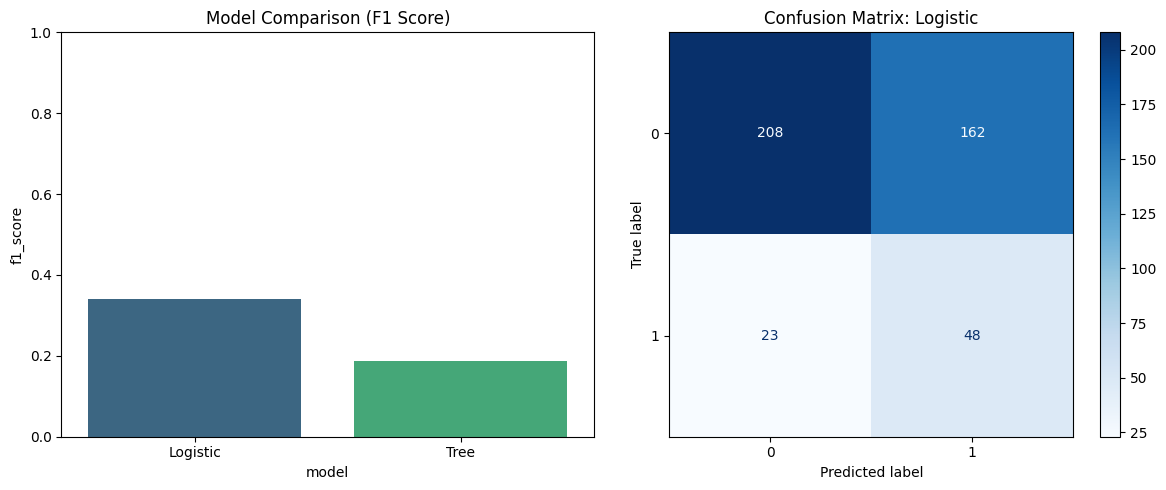

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, ConfusionMatrixDisplay

# Load data
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df["AttritionFlag"] = df["Attrition"].map({"Yes": 1, "No": 0})

# Simple features
X = df[["Age", "MonthlyIncome", "DistanceFromHome"]]
y = df["AttritionFlag"]

# Split (important: stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale data (important)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models (keep it small)
models = {
    "Logistic": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Tree": DecisionTreeClassifier(class_weight="balanced")
}

results = []
trained_models = {}
best_score = 0
best_model_name = ""

# Train and compare
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    trained_models[name] = model

    score = f1_score(y_test, pred)
    results.append({"model": name, "f1_score": score})

    print(name, "F1:", round(score, 3))

    if score > best_score:
        best_score = score
        best_model_name = name

# Final result
print("\nBest Model:", best_model_name)
print("Best F1 Score:", round(best_score, 3))

# Graphical Representation
results_df = pd.DataFrame(results)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: F1 Comparison
sns.barplot(data=results_df, x="model", y="f1_score", hue="model", ax=ax[0], palette="viridis", legend=False)
ax[0].set_title("Model Comparison (F1 Score)")
ax[0].set_ylim(0, 1)

# Plot 2: Confusion Matrix for Best Model
ConfusionMatrixDisplay.from_estimator(trained_models[best_model_name], X_test, y_test, ax=ax[1], cmap="Blues")
ax[1].set_title(f"Confusion Matrix: {best_model_name}")
plt.tight_layout()
plt.show()